In [57]:
#Exercicio 1

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)


In [58]:
# Gerei os D dígitos com "np.random.choice" e somei os b_i no loop
D = 100

sequencia = np.random.choice([0, 1], size=D)
print(sequencia)

x = 0.0
for i in range(D):
    x += sequencia[i] / 2**(i + 1)

print(f"Número gerado: x = {x:.6f}")

[0 1 1 0 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 0
 1 1 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 0
 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 0 0 1 0 0 1 1 0]
Número gerado: x = 0.437074


In [59]:
# trocando o loop pelas potências de 1/2 geradas com "np.arange"
# multiplicação elemento a elemento

potencias = 2.0 ** (-np.arange(1, D + 1))
x_vetorizado = np.sum(sequencia * potencias)

print("Potências de 1/2:", potencias)
print(f"Número gerado: x = {x_vetorizado:.6f}")

Potências de 1/2: [5.00000000e-01 2.50000000e-01 1.25000000e-01 6.25000000e-02
 3.12500000e-02 1.56250000e-02 7.81250000e-03 3.90625000e-03
 1.95312500e-03 9.76562500e-04 4.88281250e-04 2.44140625e-04
 1.22070312e-04 6.10351562e-05 3.05175781e-05 1.52587891e-05
 7.62939453e-06 3.81469727e-06 1.90734863e-06 9.53674316e-07
 4.76837158e-07 2.38418579e-07 1.19209290e-07 5.96046448e-08
 2.98023224e-08 1.49011612e-08 7.45058060e-09 3.72529030e-09
 1.86264515e-09 9.31322575e-10 4.65661287e-10 2.32830644e-10
 1.16415322e-10 5.82076609e-11 2.91038305e-11 1.45519152e-11
 7.27595761e-12 3.63797881e-12 1.81898940e-12 9.09494702e-13
 4.54747351e-13 2.27373675e-13 1.13686838e-13 5.68434189e-14
 2.84217094e-14 1.42108547e-14 7.10542736e-15 3.55271368e-15
 1.77635684e-15 8.88178420e-16 4.44089210e-16 2.22044605e-16
 1.11022302e-16 5.55111512e-17 2.77555756e-17 1.38777878e-17
 6.93889390e-18 3.46944695e-18 1.73472348e-18 8.67361738e-19
 4.33680869e-19 2.16840434e-19 1.08420217e-19 5.42101086e-20
 2.710

média binária: 0.4989, var: 0.0831
média uniforme: 0.5013, var: 0.0830
média Uniforme(0,1): 0.5000, var: 0.0833


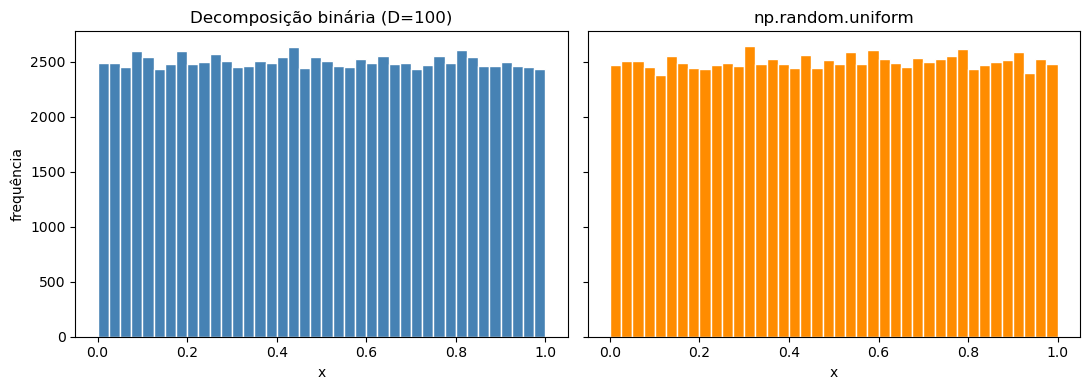

In [60]:
N = 100000

# Gerando o vetor de potências de potencias

bits_matriz = np.random.choice([0, 1], size=(N, D))

amostra_binaria = np.dot(bits_matriz, potencias) 

amostra_uniforme = np.random.uniform(0, 1, size=N)

print(f"média binária: {amostra_binaria.mean():.4f}, var: {amostra_binaria.var():.4f}")
print(f"média uniforme: {amostra_uniforme.mean():.4f}, var: {amostra_uniforme.var():.4f}")
print(f"média Uniforme(0,1): 0.5000, var: {1/12:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].hist(amostra_binaria, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title(f"Decomposição binária (D={D})")
axes[1].hist(amostra_uniforme, bins=40, color="darkorange", edgecolor="white")
axes[1].set_title("np.random.uniform")
for ax in axes:
    ax.set_xlabel("x")
axes[0].set_ylabel("frequência")
plt.tight_layout()
plt.show()

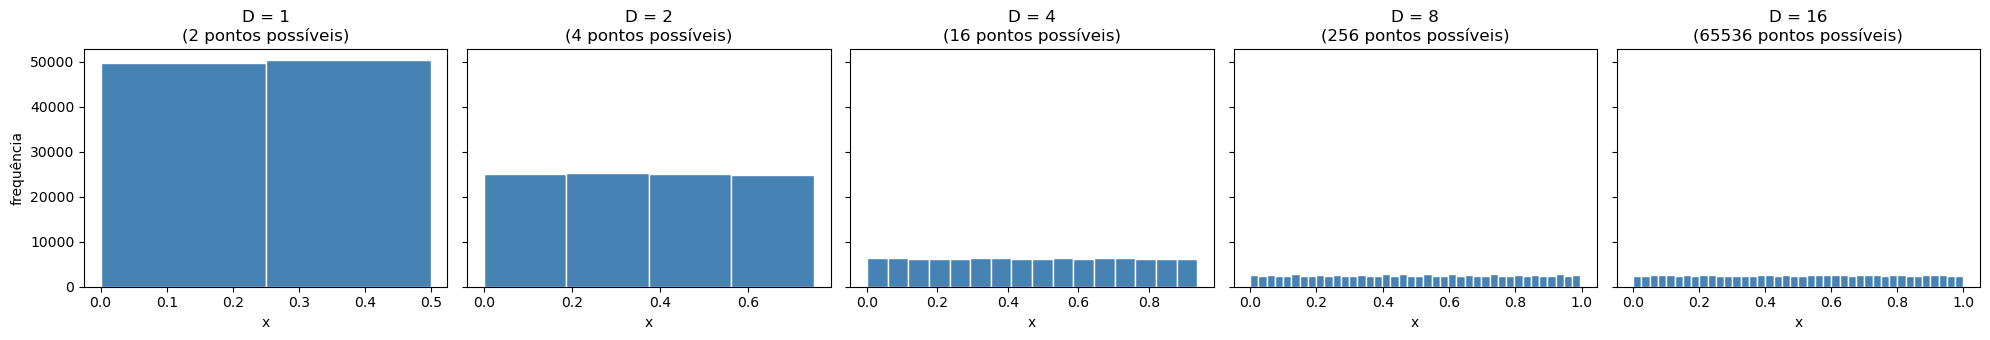

  D |  média amostral |  var amostral |  pontos na grade
  1 |          0.2514 |        0.0625 |                2
  2 |          0.3738 |        0.0780 |                4
  4 |          0.4683 |        0.0829 |               16
  8 |          0.4989 |        0.0831 |              256
 16 |          0.5014 |        0.0831 |           65,536

Teórico Uniforme(0,1): média = 0.5000, var = 0.0833


In [61]:
# Refazendo o item 3 pra vários D.

valores_D = [1, 2, 4, 8, 16]
N = 100000

fig, axes = plt.subplots(1, len(valores_D), figsize=(4 * len(valores_D), 3.5), sharey=True)

resultados = []
for ax, Dv in zip(axes, valores_D):
    pot = 2.0 ** (-np.arange(1, Dv + 1))
    bits_m = np.random.choice([0, 1], size=(N, Dv))
    
    amostra = np.dot(bits_m, pot) 

    n_pontos_grade = 2 ** Dv
    resultados.append((Dv, amostra.mean(), amostra.var(), n_pontos_grade))

    ax.hist(amostra, bins=min(40, n_pontos_grade), color="steelblue", edgecolor="white")
    ax.set_title(f"D = {Dv}\n({n_pontos_grade} pontos possíveis)")
    ax.set_xlabel("x")

axes[0].set_ylabel("frequência")
plt.tight_layout()
plt.show()

print(f"{'D':>3} | {'média amostral':>15} | {'var amostral':>13} | {'pontos na grade':>16}")
for Dv, m, v, npg in resultados:
    print(f"{Dv:>3} | {m:>15.4f} | {v:>13.4f} | {npg:>16,}")
print(f"\nTeórico Uniforme(0,1): média = 0.5000, var = {1/12:.4f}")

In [62]:
#Exercicio 2

# Gerando amostra

N = 100000
U = np.random.uniform(0, 1, size=N)

print(f"Amostra U: tamanho = {len(U)}, minimo = {U.min():.4f}, maximo = {U.max():.4f}")
print(f"Média de U: {U.mean():.4f} (teórico: 0.5)")

Amostra U: tamanho = 100000, minimo = 0.0000, maximo = 1.0000
Média de U: 0.5015 (teórico: 0.5)


In [63]:
# 2.1 — jeito manual, com for e if/else

p = 0.3

X_bernoulli_for = np.empty(N)
for i in range(N):
    if U[i] < p:
        X_bernoulli_for[i] = 1
    else:
        X_bernoulli_for[i] = 0

print("Primeiros 10 valores de U: ", np.round(U[:10], 3))
print("Primeiros 10 valores de X (Bernoulli):", X_bernoulli_for[:10])

Primeiros 10 valores de U:  [0.676 0.825 0.817 0.92  0.825 0.438 0.429 0.241 0.214 0.635]
Primeiros 10 valores de X (Bernoulli): [0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]


In [64]:
# 2.2 — a mesma coisa numa função só, sem loop
def f(u, p=p):
    return (u < p).astype(int)

X_bernoulli = f(U)

# Conferindo que bate com a versão com for
print("Métodos concordam:", np.array_equal(X_bernoulli, X_bernoulli_for))
print("Primeiros 10 valores:", X_bernoulli[:10])

Métodos concordam: True
Primeiros 10 valores: [0 0 0 0 0 0 0 1 1 0]


In [65]:
# 2.3 — média e variância batendo com a teoria

media_amostral = X_bernoulli.mean()
var_amostral = X_bernoulli.var()

media_teorica = p
var_teorica = p * (1 - p)

print(f"Média amostral:  {media_amostral:.4f}  | Média teórica E[X] = p:        {media_teorica:.4f}")
print(f"Variância amostral: {var_amostral:.4f}  | Variância teórica Var(X) = p(1-p): {var_teorica:.4f}")

Média amostral:  0.2981  | Média teórica E[X] = p:        0.3000
Variância amostral: 0.2092  | Variância teórica Var(X) = p(1-p): 0.2100


In [66]:
# 3.1 — dividindo [0,1) em 6 pedaços de tamanho 1/6 e usando o if/elif/else pra decidir a face

X_dado_for = np.empty(N, dtype=int)
for i in range(N):
    u = U[i]
    if u < 1/6:
        X_dado_for[i] = 1
    elif u < 2/6:
        X_dado_for[i] = 2
    elif u < 3/6:
        X_dado_for[i] = 3
    elif u < 4/6:
        X_dado_for[i] = 4
    elif u < 5/6:
        X_dado_for[i] = 5
    else:
        X_dado_for[i] = 6

print("Primeiros 10 resultados do dado:", X_dado_for[:10])

Primeiros 10 resultados do dado: [5 5 5 6 5 3 3 2 2 4]


In [67]:
# 3.2 — mesma lógica só que com np.select, sem precisar rodar em loop

def f_dado(u):
    condicoes = [u < 1/6, u < 2/6, u < 3/6, u < 4/6, u < 5/6, u < 6/6]
    valores = [1, 2, 3, 4, 5, 6]
    return np.select(condicoes, valores)

X_dado = f_dado(U)
print("Métodos concordam:", np.array_equal(X_dado, X_dado_for))

Métodos concordam: True


In [68]:
# 3.3 — Como U pertence à [0,6), só pegar a parte inteira e somar 1 já dá a face direto, sem nenhum if

X_dado_simples = np.floor(6 * U).astype(int) + 1

print("Métodos concordam:", np.array_equal(X_dado_simples, X_dado))
print("Primeiros 10 resultados:", X_dado_simples[:10])

Métodos concordam: True
Primeiros 10 resultados: [5 5 5 6 5 3 3 2 2 4]


In [69]:
# 3.4 — frequências de cada face
faces, contagens = np.unique(X_dado_simples, return_counts=True)
freq_relativa = contagens / N

print(f"{'Face':>5} | {'Freq. relativa':>15} | {'Teórico (1/6)':>13}")
for face, freq in zip(faces, freq_relativa):
    print(f"{face:>5} | {freq:>15.4f} | {1/6:>13.4f}")

 Face |  Freq. relativa | Teórico (1/6)
    1 |          0.1652 |        0.1667
    2 |          0.1662 |        0.1667
    3 |          0.1663 |        0.1667
    4 |          0.1669 |        0.1667
    5 |          0.1684 |        0.1667
    6 |          0.1671 |        0.1667


In [70]:
# 3.5 — média e variância, usando Var(X)=E[X^2]-E[X]^2.

media_dado = X_dado_simples.mean()
var_dado = (X_dado_simples**2).mean() - media_dado**2

media_teorica_dado = np.mean(np.arange(1, 7))
var_teorica_dado = np.mean(np.arange(1, 7)**2) - media_teorica_dado**2

print(f"Média amostral:    {media_dado:.4f} | Média teórica:    {media_teorica_dado:.4f}")
print(f"Variância amostral: {var_dado:.4f} | Variância teórica: {var_teorica_dado:.4f}")

Média amostral:    3.5084 | Média teórica:    3.5000
Variância amostral: 2.9125 | Variância teórica: 2.9167


In [71]:
# 3.6 — Agora os intervalos não têm todos 1/6: usei a soma acumulada das probabilidades como limiares.
probs = np.array([0.05, 0.10, 0.15, 0.20, 0.20, 0.30])
probs_acumuladas = np.cumsum(probs) 

def f_dado_viciado(u, cdf=probs_acumuladas):
    condicoes = [u < c for c in cdf]
    valores = [1, 2, 3, 4, 5, 6]
    return np.select(condicoes, valores)

X_viciado = f_dado_viciado(U)

faces_v, contagens_v = np.unique(X_viciado, return_counts=True)
freq_v = contagens_v / N

print(f"{'Face':>5} | {'Freq. relativa':>15} | {'P(X=face) teórico':>18}")
for face, freq, pteo in zip(faces_v, freq_v, probs):
    print(f"{face:>5} | {freq:>15.4f} | {pteo:>18.4f}")

media_viciado = X_viciado.mean()
var_viciado = (X_viciado**2).mean() - media_viciado**2

media_teorica_v = np.sum(np.arange(1, 7) * probs)
var_teorica_v = np.sum(np.arange(1, 7)**2 * probs) - media_teorica_v**2

print(f"\nMédia amostral:    {media_viciado:.4f} | Média teórica:    {media_teorica_v:.4f}")
print(f"Variância amostral: {var_viciado:.4f} | Variância teórica: {var_teorica_v:.4f}")

 Face |  Freq. relativa |  P(X=face) teórico
    1 |          0.0498 |             0.0500
    2 |          0.0991 |             0.1000
    3 |          0.1491 |             0.1500
    4 |          0.1996 |             0.2000
    5 |          0.2002 |             0.2000
    6 |          0.3021 |             0.3000

Média amostral:    4.3076 | Média teórica:    4.3000
Variância amostral: 2.3083 | Variância teórica: 2.3100


In [72]:
# 4.1 — Pra gerar a binomial eu monto uma matriz (N,n) de uniformes, transformo tudo em Bernoulli com a função "f" de antes e somo cada linha
n_binom = 20
p_binom = 0.3

U_binom = np.random.uniform(0, 1, size=(N, n_binom))
bernoullis = f(U_binom, p=p_binom)
X_binom = bernoullis.sum(axis=1)

print("Primeiros 10 valores da amostra binomial:", X_binom[:10])

Primeiros 10 valores da amostra binomial: [6 7 9 6 7 8 7 5 6 7]


In [73]:
# 4.2 — conferindo média e variância.
media_binom = X_binom.mean()
var_binom = X_binom.var()

media_teo_binom = n_binom * p_binom
var_teo_binom = n_binom * p_binom * (1 - p_binom)

print(f"Média amostral:    {media_binom:.4f} | Média teórica np:      {media_teo_binom:.4f}")
print(f"Variância amostral: {var_binom:.4f} | Variância teórica np(1-p): {var_teo_binom:.4f}")

Média amostral:    6.0037 | Média teórica np:      6.0000
Variância amostral: 4.2101 | Variância teórica np(1-p): 4.2000


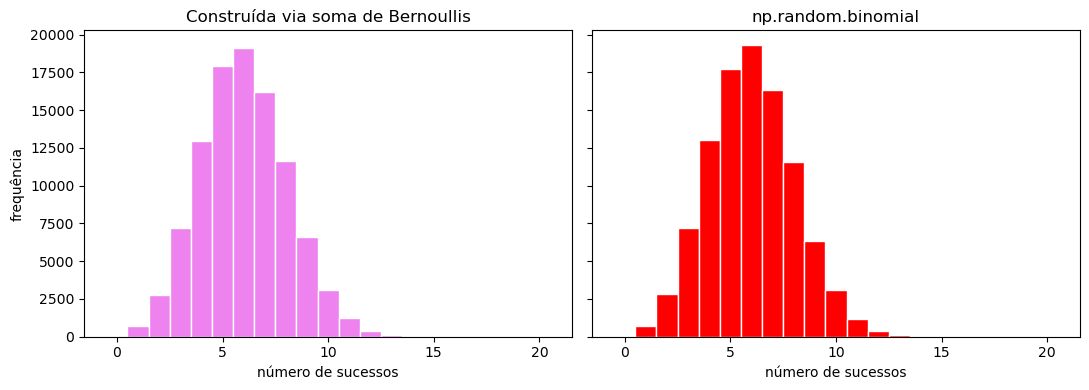

np.random.binomial -> média: 5.9968, var: 4.2181


In [74]:
# 4.3 — e comparando com a função pronta do numpy.
X_binom_numpy = np.random.binomial(n_binom, p_binom, size=N)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, sharex=True)
axes[0].hist(X_binom, bins=np.arange(-0.5, n_binom + 1.5), color="violet", edgecolor="white")
axes[0].set_title("Construída via soma de Bernoullis")
axes[1].hist(X_binom_numpy, bins=np.arange(-0.5, n_binom + 1.5), color="red", edgecolor="white")
axes[1].set_title("np.random.binomial")
for ax in axes:
    ax.set_xlabel("número de sucessos")
axes[0].set_ylabel("frequência")
plt.tight_layout()
plt.show()

print(f"np.random.binomial -> média: {X_binom_numpy.mean():.4f}, var: {X_binom_numpy.var():.4f}")

In [75]:
# 5.1 — uma rodada só: n lançamentos do dado de 4 faces, reaproveitando a ideia das probabilidades acumuladas.
n_multi = 50
probs_multi = np.array([0.10, 0.20, 0.30, 0.40])
cdf_multi = np.cumsum(probs_multi)
k = len(probs_multi)

def f_multi(u, cdf=cdf_multi):
    condicoes = [u < c for c in cdf]
    valores = [1, 2, 3, 4]
    return np.select(condicoes, valores)

U_uma_realizacao = np.random.uniform(0, 1, size=n_multi)
faces_uma_realizacao = f_multi(U_uma_realizacao)

contagem_uma_realizacao = np.array([(faces_uma_realizacao == i).sum() for i in range(1, k + 1)])
print("Contagem de cada face em uma realização:", contagem_uma_realizacao)
print("Soma das contagens:", contagem_uma_realizacao.sum())

Contagem de cada face em uma realização: [ 7 12 14 17]
Soma das contagens: 50


In [76]:
# 5.2 — agora repetindo N vezes: gero uma matriz (N,n) de uniformes de uma vez
# transformo tudo em faces e conto quantas vezes cada face saiu em cada linha

U_multi = np.random.uniform(0, 1, size=(N, n_multi))
faces_multi = f_multi(U_multi)  # matriz (N, n) com valores em {1,2,3,4}

# Para cada k, conta quantas vezes a face k aparece em cada linha
X_multi = np.stack([(faces_multi == i).sum(axis=1) for i in range(1, k + 1)], axis=1)
# Cada linha soma n_multi

print("Formato da amostra:", X_multi.shape)
print("Primeiras 5 realizações:")
print(X_multi[:5])

Formato da amostra: (100000, 4)
Primeiras 5 realizações:
[[ 5  7 16 22]
 [ 8  7 17 18]
 [ 4 13  8 25]
 [ 4 12 14 20]
 [ 6 10 13 21]]


In [77]:
# 5.3 — média de cada X_i contra np_i.

medias_multi = X_multi.mean(axis=0)
medias_teoricas = n_multi * probs_multi

print(f"{'Face':>5} | {'Média amostral':>15} | {'np_i teórico':>13}")
for i in range(k):
    print(f"{i+1:>5} | {medias_multi[i]:>15.4f} | {medias_teoricas[i]:>13.4f}")

 Face |  Média amostral |  np_i teórico
    1 |          4.9989 |        5.0000
    2 |         10.0044 |       10.0000
    3 |         15.0024 |       15.0000
    4 |         19.9943 |       20.0000


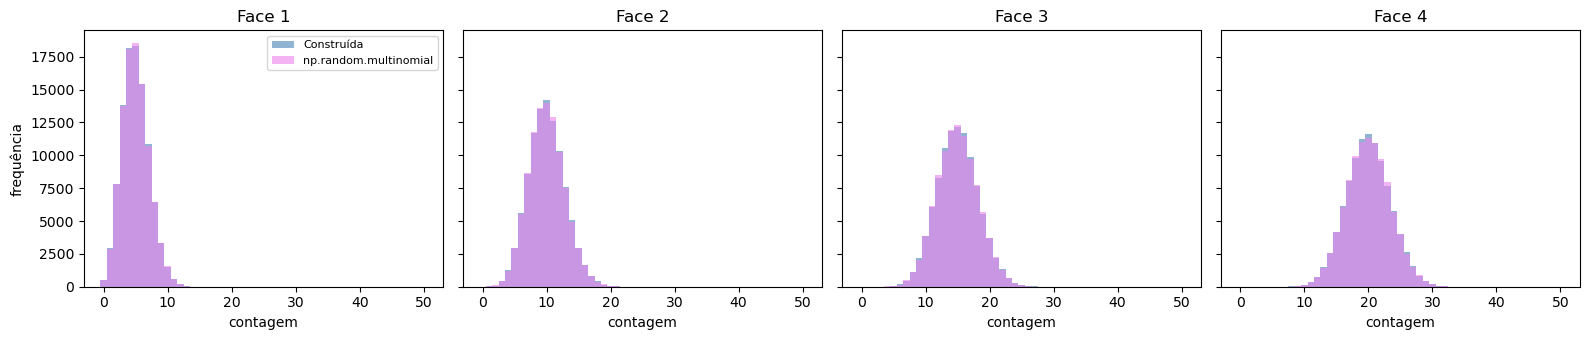

Médias (numpy):    [ 4.99906  9.9994  14.99732 20.00422]
Médias (meu método): [ 4.99893 10.00437 15.00237 19.99433]


In [78]:
#5.4 — comparando com np.random.multinomial

X_multi_numpy = np.random.multinomial(n_multi, probs_multi, size=N)

fig, axes = plt.subplots(1, k, figsize=(4 * k, 3.5), sharey=True)
for i, ax in enumerate(axes):
    bins = np.arange(-0.5, n_multi + 1.5)
    ax.hist(X_multi[:, i], bins=bins, alpha=0.6, label="Construída", color="steelblue")
    ax.hist(X_multi_numpy[:, i], bins=bins, alpha=0.6, label="np.random.multinomial", color="violet")
    ax.set_title(f"Face {i+1}")
    ax.set_xlabel("contagem")
axes[0].set_ylabel("frequência")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Médias (numpy):   ", X_multi_numpy.mean(axis=0))
print("Médias (meu método):", medias_multi)

In [79]:
# 5.5 — só confirmando que a soma das 4 contagens dá sempre n

somas_por_realizacao = X_multi.sum(axis=1)

print("Todas as somas são iguais a n?", np.all(somas_por_realizacao == n_multi))
print("Valores únicos observados na soma:", np.unique(somas_por_realizacao))

Todas as somas são iguais a n? True
Valores únicos observados na soma: [50]


In [80]:
# 5.6 — variância de cada face

variancias_multi = X_multi.var(axis=0)
variancias_teoricas = n_multi * probs_multi * (1 - probs_multi)

print(f"{'Face':>5} | {'Var. amostral':>14} | {'np_i(1-p_i) teórico':>20}")
for i in range(k):
    print(f"{i+1:>5} | {variancias_multi[i]:>14.4f} | {variancias_teoricas[i]:>20.4f}")

 Face |  Var. amostral |  np_i(1-p_i) teórico
    1 |         4.4982 |               4.5000
    2 |         7.9825 |               8.0000
    3 |        10.4617 |              10.5000
    4 |        11.9178 |              12.0000


In [81]:
# 5.7 — covariância entre duas faces (escolhi 1 e 2), comparando com -np_ip_j
i_face, j_face = 0, 1

cov_amostral = np.cov(X_multi[:, i_face], X_multi[:, j_face])[0, 1]
cov_teorica = -n_multi * probs_multi[i_face] * probs_multi[j_face]

print(f"Cov. amostral entre faces {i_face+1} e {j_face+1}: {cov_amostral:.4f}")
print(f"Cov. teórica: {cov_teorica:.4f}")

Cov. amostral entre faces 1 e 2: -1.0045
Cov. teórica: -1.0000
